<a href="https://colab.research.google.com/github/Priya-Kumari-Chourasia/ml_algo/blob/main/sgd_classifier_practise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

In [73]:
orders = pd.read_csv('/content/Orders.csv')
customers = pd.read_csv('/content/Customers.csv')
products = pd.read_csv('/content/Products.csv')
returns = pd.read_csv('/content/Returns.csv')
order_items = pd.read_csv('/content/Order_Items.csv')

In [74]:
orders.head()

,order_id,customer_id,order_date,order_status,payment_method,sales_channel,gross_amount,discount_amount,shipping_fee,final_amount,delivered_date
0,O00001,C0047,10-06-2024,Delivered,Debit Card,Mobile App,424.15,74.85,49,473.15,14-06-2024
1,O00002,C0016,18-02-2025,Delivered,Credit Card,Website,349.00,0.00,40,389.00,21-02-2025
2,O00003,C0191,03-12-2025,Delivered,Credit Card,Website,1467.40,229.60,0,1467.40,09-12-2025
3,O00004,C0087,10-08-2025,Delivered,Credit Card,Website,663.10,34.90,49,712.10,17-08-2025
4,O00005,C0211,17-07-2025,Delivered,UPI,Website,1511.35,134.65,0,1511.35,23-07-2025


In [75]:
customers.head()

,customer_id,customer_name,city,state,gender,age_group,signup_date,acquisition_channel
0,C0001,Ayaan Gupta,Hyderabad,Telangana,Female,35-44,08-09-2023,YouTube
1,C0002,Aarav Sharma,Gurugram,Haryana,Female,25-34,02-02-2023,Instagram
2,C0003,Kavya Kapoor,Noida,Uttar Pradesh,Other,18-24,23-07-2023,Google Search
3,C0004,Karan Mehta,Kochi,Kerala,Other,25-34,07-01-2023,YouTube
4,C0005,Vihaan Sharma,Lucknow,Uttar Pradesh,Male,18-24,11-12-2023,Google Search


In [76]:
products.head()

,product_id,product_name,category,concern,skin_type,key_ingredient,size,mrp,cost_price,stock_qty,launch_date
0,P001,2% Salicylic Acid Face Serum,Serum,Acne Control,Oily / Acne-Prone,Salicylic Acid,30ml,549,247,220,15-01-2022
1,P002,10% Niacinamide Face Serum,Serum,Oil Control,Oily / Combination,Niacinamide,30ml,599,265,240,10-09-2021
2,P003,Vitamin C 10% Face Serum,Serum,Brightening,All Skin Types,Vitamin C,30ml,699,315,180,01-05-2022
3,P004,Alpha Arbutin 2% Serum,Serum,Pigmentation,All Skin Types,Alpha Arbutin,30ml,649,292,160,18-03-2022
4,P005,Retinol 0.3% Face Serum,Serum,Anti-Ageing,Normal / Dry,Retinol,30ml,699,318,140,11-08-2022


In [77]:
returns.head()

,return_id,order_id,product_id,return_date,return_reason,refund_status
0,R00001,O00011,P003,31-03-2024,Late delivery,Under Review
1,R00002,O00023,P007,17-05-2025,Skin irritation,Replacement Sent
2,R00003,O00032,P024,18-07-2024,Skin irritation,Refunded
3,R00004,O00062,P027,10-04-2024,Changed mind,Under Review
4,R00005,O00130,P017,26-08-2024,Skin irritation,Replacement Sent


In [78]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_id         1250 non-null   object 
 1   customer_id      1250 non-null   object 
 2   order_date       1250 non-null   object 
 3   order_status     1250 non-null   object 
 4   payment_method   1250 non-null   object 
 5   sales_channel    1250 non-null   object 
 6   gross_amount     1250 non-null   float64
 7   discount_amount  1250 non-null   float64
 8   shipping_fee     1250 non-null   int64  
 9   final_amount     1250 non-null   float64
 10  delivered_date   1099 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 107.6+ KB


In [79]:
returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   return_id      79 non-null     object
 1   order_id       79 non-null     object
 2   product_id     79 non-null     object
 3   return_date    79 non-null     object
 4   return_reason  79 non-null     object
 5   refund_status  79 non-null     object
dtypes: object(6)
memory usage: 3.8+ KB


In [80]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          500 non-null    object
 1   customer_name        500 non-null    object
 2   city                 500 non-null    object
 3   state                500 non-null    object
 4   gender               500 non-null    object
 5   age_group            500 non-null    object
 6   signup_date          500 non-null    object
 7   acquisition_channel  500 non-null    object
dtypes: object(8)
memory usage: 31.4+ KB


In [81]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2042 entries, 0 to 2041
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_item_id  2042 non-null   object 
 1   order_id       2042 non-null   object 
 2   product_id     2042 non-null   object 
 3   quantity       2042 non-null   int64  
 4   unit_price     2042 non-null   int64  
 5   discount_pct   2042 non-null   int64  
 6   item_total     2042 non-null   float64
dtypes: float64(1), int64(3), object(3)
memory usage: 111.8+ KB


In [82]:
# Clean string columns in Returns
returns['order_id'] = returns['order_id'].astype(str).str.strip()
returns['product_id'] = returns['product_id'].astype(str).str.strip()

# Clean string columns in Order Items
order_items['order_id'] = order_items['order_id'].astype(str).str.strip()
order_items['product_id'] = order_items['product_id'].astype(str).str.strip()

In [83]:
returned_pairs = set(zip(returns['order_id'],returns['product_id']))

In [84]:
order_items['is_returned'] = order_items.apply(lambda x: 1 if (x['order_id'],x['product_id']) in returned_pairs else 0,axis=1)

In [85]:
order_items.info()
order_items.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2042 entries, 0 to 2041
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_item_id  2042 non-null   object 
 1   order_id       2042 non-null   object 
 2   product_id     2042 non-null   object 
 3   quantity       2042 non-null   int64  
 4   unit_price     2042 non-null   int64  
 5   discount_pct   2042 non-null   int64  
 6   item_total     2042 non-null   float64
 7   is_returned    2042 non-null   int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 127.8+ KB


,order_item_id,order_id,product_id,quantity,unit_price,discount_pct,item_total,is_returned
690,OI000691,O00417,P014,2,499,0,998.00,0
512,OI000513,O00311,P003,2,699,5,1328.10,0
1040,OI001041,O00632,P013,1,399,5,379.05,0
1621,OI001622,O00995,P006,2,599,5,1138.10,0
1427,OI001428,O00876,P025,1,599,0,599.00,0


In [86]:
df = order_items.merge(orders,on='order_id',how='left')
df.sample(10)

,order_item_id,order_id,product_id,quantity,unit_price,discount_pct,item_total,is_returned,customer_id,order_date,order_status,payment_method,sales_channel,gross_amount,discount_amount,shipping_fee,final_amount,delivered_date
1065,OI001066,O00646,P012,1,449,10,404.10,0,C0230,21-07-2024,Delivered,UPI,Website,404.10,44.90,49,453.10,25-07-2024
1054,OI001055,O00639,P004,1,649,10,584.10,0,C0374,14-06-2024,Delivered,Credit Card,Mobile App,584.10,64.90,40,624.10,18-06-2024
1053,OI001054,O00638,P018,1,349,15,296.65,0,C0485,20-08-2025,Delivered,Net Banking,Marketplace,296.65,52.35,40,336.65,25-08-2025
173,OI000174,O00104,P023,2,499,10,898.20,0,C0065,14-05-2024,Delivered,UPI,Website,1896.50,249.50,0,1896.50,18-05-2024
993,OI000994,O00603,P019,1,399,5,379.05,0,C0079,12-07-2024,Delivered,UPI,Website,753.30,144.70,0,753.30,15-07-2024
361,OI000362,O00223,P013,2,399,15,678.30,0,C0211,14-12-2024,Delivered,UPI,Website,940.05,206.95,0,940.05,20-12-2024
1887,OI001888,O01162,P006,1,599,10,539.10,1,C0071,13-07-2025,Returned,COD,Website,539.10,59.90,59,598.10,15-07-2025
1156,OI001157,O00704,P014,2,499,0,998.00,0,C0386,06-07-2025,Delivered,UPI,Website,2654.10,39.90,0,2654.10,11-07-2025
1770,OI001771,O01087,P021,1,399,0,399.00,0,C0228,09-12-2025,Delivered,Debit Card,Marketplace,748.00,0.00,0,748.00,13-12-2025
1325,OI001326,O00814,P009,1,349,5,331.55,0,C0020,23-10-2024,Delivered,Net Banking,Website,1998.80,147.20,0,1998.80,26-10-2024


In [87]:
df = df.merge(customers,on='customer_id',how='left')
df.sample(10)

,order_item_id,order_id,product_id,quantity,unit_price,discount_pct,item_total,is_returned,customer_id,order_date,...,shipping_fee,final_amount,delivered_date,customer_name,city,state,gender,age_group,signup_date,acquisition_channel
1348,OI001349,O00828,P019,2,399,10,718.20,0,C0297,28-01-2025,...,0,718.20,03-02-2025,Ayaan Gupta,Pune,Maharashtra,Male,18-24,05-04-2024,Instagram
1175,OI001176,O00715,P004,1,649,10,584.10,1,C0184,01-05-2025,...,49,633.10,06-05-2025,Reyansh Rao,Kolkata,West Bengal,Female,35-44,21-07-2024,Instagram
1300,OI001301,O00797,P007,1,699,15,594.15,0,C0273,07-11-2025,...,0,1193.15,NaN,Vivaan Chopra,Indore,Madhya Pradesh,Male,25-34,03-08-2024,Instagram
1229,OI001230,O00746,P016,1,299,5,284.05,0,C0136,09-05-2025,...,0,1612.15,13-05-2025,Priya Agarwal,Lucknow,Uttar Pradesh,Male,25-34,23-10-2023,Referral
1534,OI001535,O00943,P022,1,499,0,499.00,0,C0162,23-11-2025,...,49,548.00,29-11-2025,Kavya Iyer,Indore,Madhya Pradesh,Other,25-34,10-03-2024,Google Search
402,OI000403,O00247,P006,1,599,15,509.15,0,C0442,15-08-2025,...,40,549.15,19-08-2025,Aarav Nair,Kochi,Kerala,Male,18-24,01-08-2024,Instagram
741,OI000742,O00445,P004,1,649,20,519.20,0,C0017,30-04-2024,...,40,559.20,NaN,Rahul Jain,Delhi,Delhi,Female,18-24,13-06-2023,Google Search
1324,OI001325,O00814,P019,1,399,15,339.15,0,C0020,23-10-2024,...,0,1998.80,26-10-2024,Kiara Shah,Lucknow,Uttar Pradesh,Female,25-34,11-06-2023,Website Direct
130,OI000131,O00076,P014,1,499,25,374.25,0,C0470,10-04-2025,...,0,2037.90,13-04-2025,Rohan Agarwal,Hyderabad,Telangana,Female,35-44,26-08-2024,Google Search
2015,OI002016,O01235,P001,1,549,5,521.55,1,C0431,23-09-2025,...,0,1000.75,25-09-2025,Yash Reddy,Nagpur,Maharashtra,Male,18-24,20-09-2024,Google Search


In [88]:
df = df.merge(products,on='product_id',how='left')
df.sample(10)

,order_item_id,order_id,product_id,quantity,unit_price,discount_pct,item_total,is_returned,customer_id,order_date,...,product_name,category,concern,skin_type,key_ingredient,size,mrp,cost_price,stock_qty,launch_date
1850,OI001851,O01138,P013,1,399,10,359.10,0,C0291,04-10-2025,...,SPF 50 Sunscreen,Sunscreen,Sun Protection,All Skin Types,SPF 50,50g,399,168,350,12-02-2022
273,OI000274,O00165,P012,2,449,0,898.00,0,C0291,16-12-2024,...,Marula Oil 5% Moisturizer,Moisturizer,Nourishment,Dry,Marula Oil,50g,449,197,190,05-01-2023
1143,OI001144,O00697,P014,1,499,25,374.25,1,C0441,07-12-2024,...,SPF 60 PA++++ Sunscreen,Sunscreen,Sun Protection,All Skin Types,SPF 60,50g,499,211,260,10-03-2023
469,OI000470,O00283,P024,1,799,5,759.05,0,C0317,29-10-2025,...,Hair Growth Actives Serum,Hair Care,Hair Growth,Scalp Care,Redensyl,60ml,799,372,160,14-02-2023
1385,OI001386,O00851,P002,1,599,10,539.10,0,C0150,15-08-2025,...,10% Niacinamide Face Serum,Serum,Oil Control,Oily / Combination,Niacinamide,30ml,599,265,240,10-09-2021
565,OI000566,O00345,P002,1,599,5,569.05,1,C0120,22-01-2024,...,10% Niacinamide Face Serum,Serum,Oil Control,Oily / Combination,Niacinamide,30ml,599,265,240,10-09-2021
1639,OI001640,O01007,P009,1,349,25,261.75,1,C0018,25-04-2025,...,Ceramide Moisturizer,Moisturizer,Barrier Repair,Dry / Sensitive,Ceramide,50g,349,145,300,01-10-2022
1060,OI001061,O00644,P013,1,399,10,359.10,0,C0255,16-07-2024,...,SPF 50 Sunscreen,Sunscreen,Sun Protection,All Skin Types,SPF 50,50g,399,168,350,12-02-2022
417,OI000418,O00254,P021,1,399,5,379.05,0,C0476,09-04-2025,...,Caffeine Under Eye Cream,Eye Care,Dark Circles,All Skin Types,Caffeine,30g,399,157,150,08-12-2022
686,OI000687,O00415,P027,2,399,0,798.00,0,C0360,30-03-2024,...,Body Wash with Salicylic Acid,Body Care,Body Acne,Oily / Acne-Prone,Salicylic Acid,200ml,399,159,240,01-11-2023


In [89]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier

In [90]:
categorical_features = ['category','skin_type','gender','age_group','payment_method','sales_channel']
numeric_features =['quantity','unit_price','discount_pct','shipping_fee']

x = df[categorical_features+numeric_features]
y=df['is_returned']



In [91]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)

In [92]:
numeric_transformer = Pipeline(steps=[('scaler',StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot',OneHotEncoder(handle_unknown='ignore'))])

In [93]:
preprocessor = ColumnTransformer(transformers=[
    ('num',numeric_transformer,numeric_features),
    ('cat',categorical_transformer,categorical_features)

])

In [94]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['quantity', 'unit_price', 'discount_pct',
                                  'shipping_fee']),
                                ('cat',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['category', 'skin_type', 'gender',
                                  'age_group', 'payment_method',
                                  'sales_channel'])])

In [129]:
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SGDClassifier(
        loss='log_loss',      # Enables probabilistic outputs (Logistic Regression via SGD)
        penalty='l2',         # Adds regularization to prevent overfitting
        alpha=0.01,          # Regularization strength
        max_iter=1000,        # Maximum passes over the data
        random_state=42,
        class_weight='balanced'
    ))
])

In [130]:
model_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['quantity', 'unit_price',
                                                   'discount_pct',
                                                   'shipping_fee']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['category', 'skin_type',
                                                   'gender', 'age_group',
                                                   'payment_method',
                                                   'sales_channel'])])),
                ('classifier',
                 SGDClassifier(alpha=0.01, class_weight='balanced',
                               loss='log_loss', random_state=42))])

In [131]:
y_pred = model_pipeline.predict(x_test)
y_probs = model_pipeline.predict_proba(x_test)[:,1]


In [132]:
y_test.value_counts()

,count
is_returned,
0,387
1,22


In [133]:
y_train.isnull().sum()

np.int64(0)

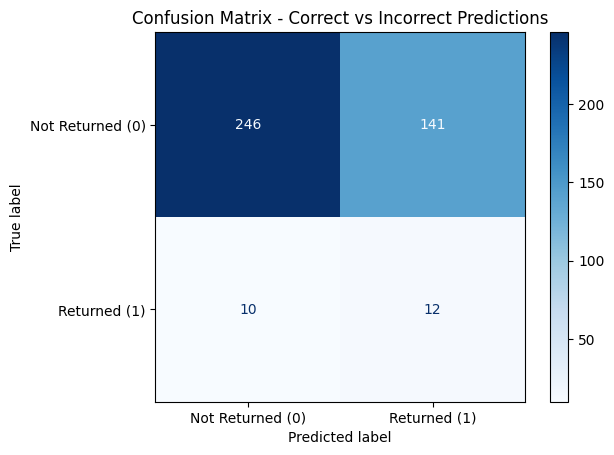

In [134]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the confusion matrix data
cm = confusion_matrix(y_test, y_pred)

# Display the plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Returned (0)', 'Returned (1)'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Correct vs Incorrect Predictions")
plt.show()

/tmp/ipykernel_1791/4255763523.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=results, palette=['#2ecc71', '#e74c3c'])


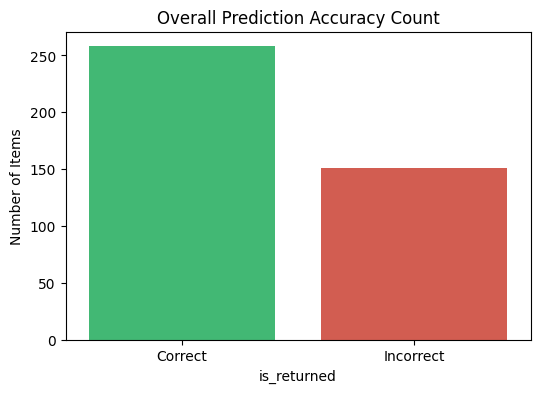

is_returned
Correct      258
Incorrect    151
Name: count, dtype: int64


In [135]:
import seaborn as sns

# Check where predictions match the actual test labels
results = (y_pred == y_test).map({True: 'Correct', False: 'Incorrect'})

# Plot the counts
plt.figure(figsize=(6, 4))
sns.countplot(x=results, palette=['#2ecc71', '#e74c3c'])
plt.title("Overall Prediction Accuracy Count")
plt.ylabel("Number of Items")
plt.show()

# Print the text summary alongside it
print(results.value_counts())